In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, auc, precision_recall_curve,
                             average_precision_score)

import shap

plt.style.use('fivethirtyeight')
sns.set_palette("Set2")

In [3]:
# Load data
df = pd.read_csv('fraud_oracle.csv')

print("Data Shape:", df.shape)
print("\nFirst few rows of data:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nTarget Variable Distribution:")
if 'FraudFound_P' in df.columns:  # CHANGED THIS LINE
    fraud_counts = df['FraudFound_P'].value_counts()  # CHANGED THIS LINE
    print(fraud_counts)
    print(f"Fraud Rate: {fraud_counts[1] / len(df) * 100:.2f}%")  # CHANGED 'Y' to 1
else:
    print("Target variable 'FraudFound_P' not found. Checking for similar columns:")  # CHANGED THIS LINE
    print(df.columns.tolist())

missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Percentage', ascending=False)

print("\nColumns with missing values:")
print(missing_df)

Data Shape: (15420, 33)

First few rows of data:
  Month  WeekOfMonth  DayOfWeek    Make AccidentArea DayOfWeekClaimed  \
0   Dec            5  Wednesday   Honda        Urban          Tuesday   
1   Jan            3  Wednesday   Honda        Urban           Monday   
2   Oct            5     Friday   Honda        Urban         Thursday   
3   Jun            2   Saturday  Toyota        Rural           Friday   
4   Jan            5     Monday   Honda        Urban          Tuesday   

  MonthClaimed  WeekOfMonthClaimed     Sex MaritalStatus  ...  AgeOfVehicle  \
0          Jan                   1  Female        Single  ...       3 years   
1          Jan                   4    Male        Single  ...       6 years   
2          Nov                   2    Male       Married  ...       7 years   
3          Jul                   1    Male       Married  ...   more than 7   
4          Feb                   2  Female        Single  ...       5 years   

  AgeOfPolicyHolder PoliceReportFiled

In [8]:
#print(df['FraudFound_P'])

In [10]:
print("Test phase___")

data = df.copy()

# investigate why I am still getting nan and the graph 

target_col = 'FraudFound_P'  # Changed from the fallback logic
print(f"Using '{target_col}' as target variable")

if data[target_col].dtype == 'object':
    data[target_col] = data[target_col].map({'Y': 1, 'N': 0, 'Yes': 1, 'No': 0})
else:
    data[target_col] = data[target_col].astype(int)

categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

print(f"Categorical columns: {len(categorical_cols)}")
print(f"Numerical columns: {len(numerical_cols)}")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

print("Categorical variables encoded.")

if 'total_claim_amount' in data.columns and 'policy_annual_premium' in data.columns:
    data['claim_to_premium_ratio'] = data['total_claim_amount'] / data['policy_annual_premium']
    numerical_cols.append('claim_to_premium_ratio')

if 'policy_effective_date' in data.columns and 'incident_date' in data.columns:
    if data['policy_effective_date'].dtype == 'object':
        data['policy_effective_date'] = pd.to_datetime(data['policy_effective_date'])
    if data['incident_date'].dtype == 'object':
        data['incident_date'] = pd.to_datetime(data['incident_date'])
    
    data['customer_tenure_days'] = (data['incident_date'] - data['policy_effective_date']).dt.days
    numerical_cols.append('customer_tenure_days')

if 'incident_state' in data.columns:
    state_fraud_rates = data.groupby('incident_state')[target_col].mean()
    high_risk_states = state_fraud_rates[state_fraud_rates > state_fraud_rates.median()].index
    data['high_risk_geography'] = data['incident_state'].isin(high_risk_states).astype(int)
    numerical_cols.append('high_risk_geography')

print("Feature engineering completed.")

X = data.drop(target_col, axis=1)
y = data[target_col]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Fraud rate: {y.mean():.4f}")

Test phase___
Using 'FraudFound_P' as target variable
Categorical columns: 24
Numerical columns: 8
Categorical variables encoded.
Feature engineering completed.
Features shape: (15420, 32)
Target shape: (15420,)
Fraud rate: 0.0599


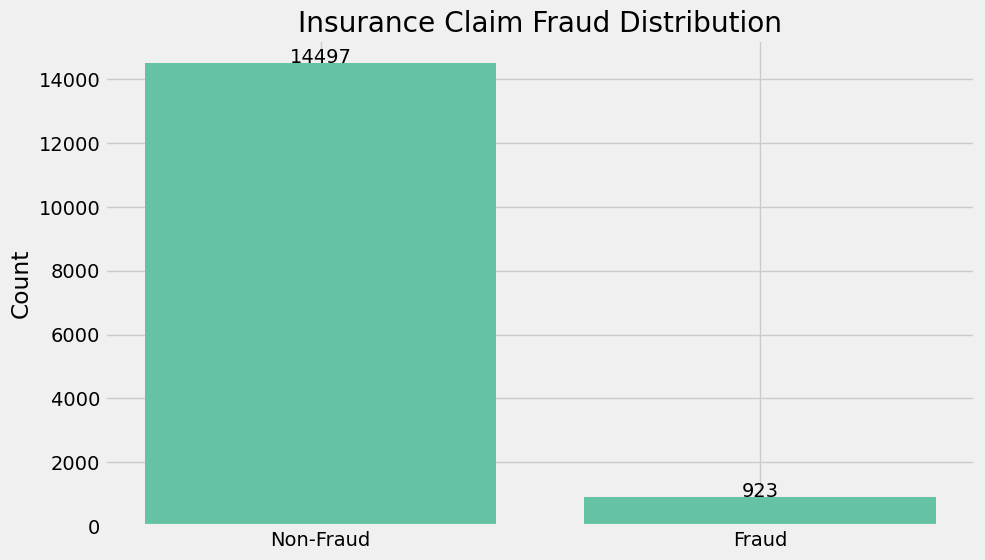

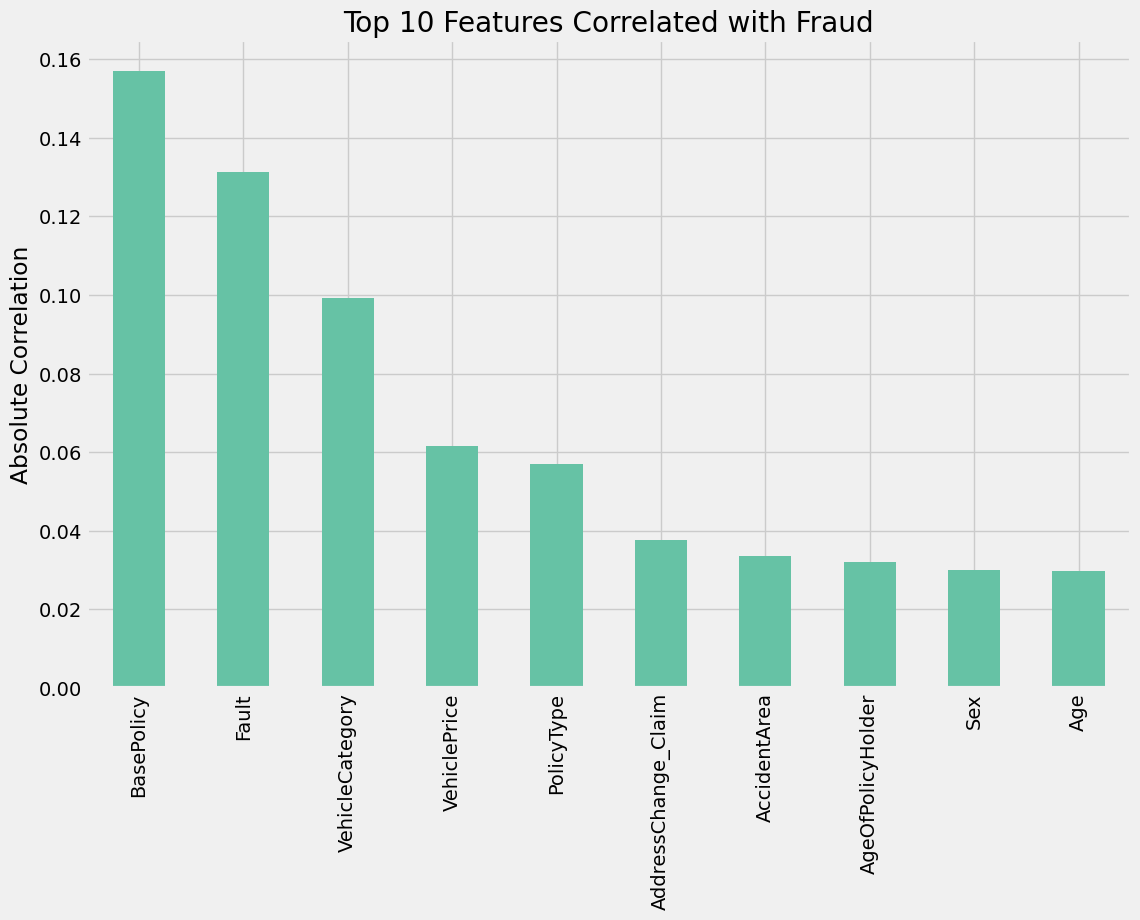

No feature columns found for distribution plots.


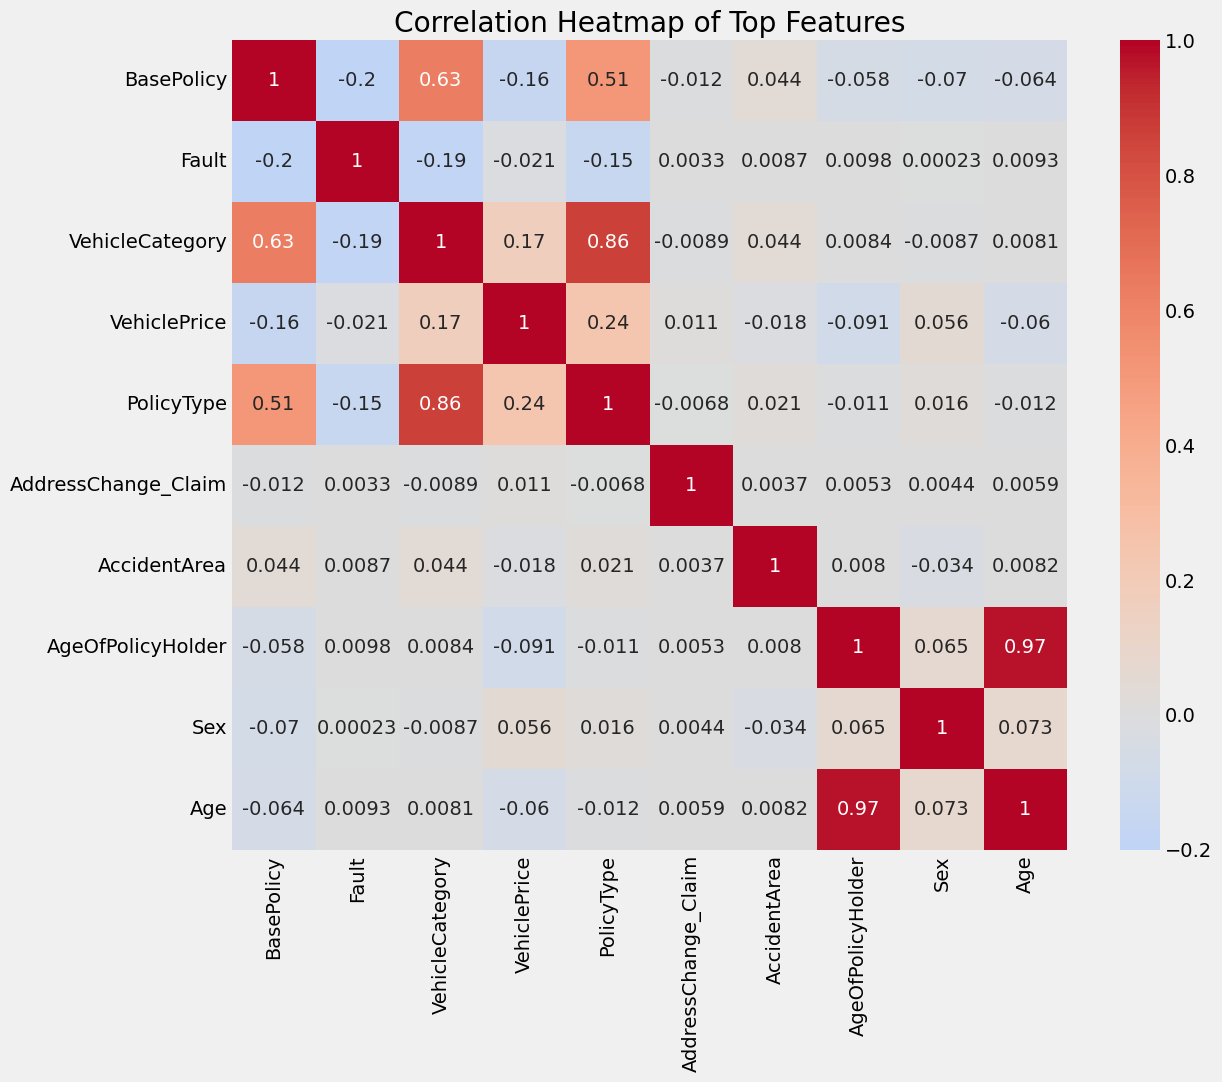

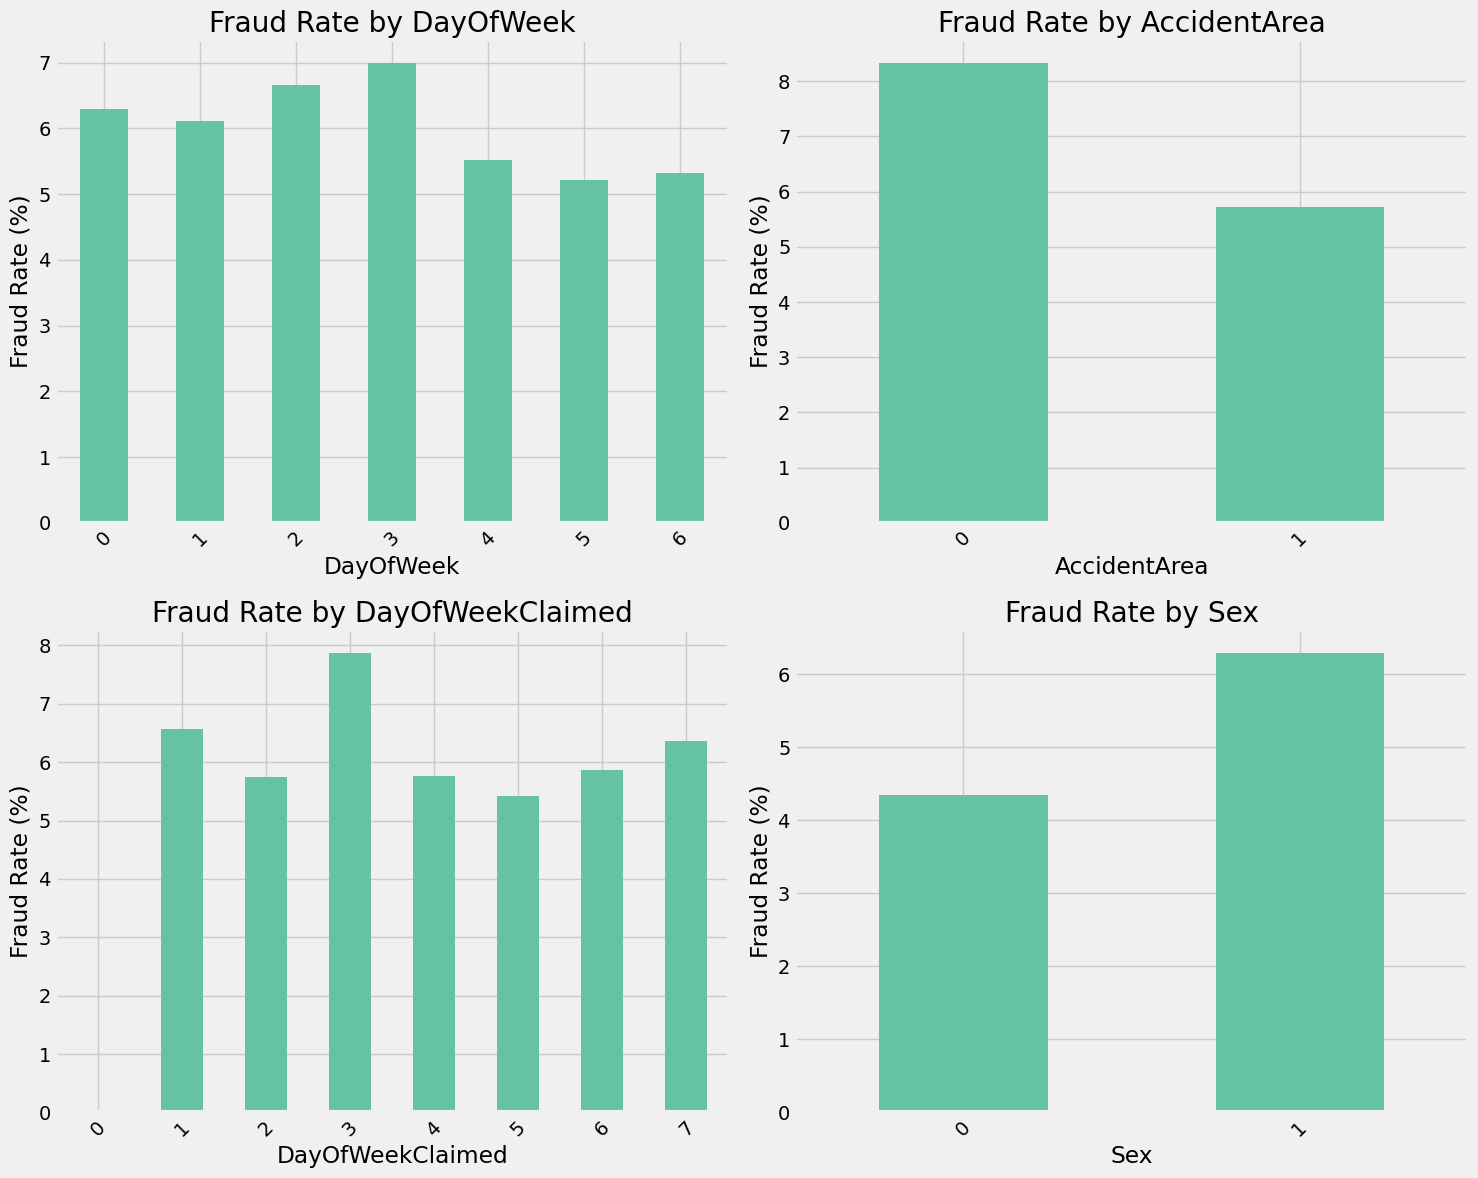

In [14]:
if 'y' not in locals() and 'y' not in globals():
    print("Error: Target variable 'y' is not defined.")
elif len(y) == 0:
    print("Error: Target variable 'y' is empty.")
else:
    plt.figure(figsize=(10, 6))
    fraud_counts = y.value_counts()

    if len(fraud_counts) == 0:
        print("Error: No values found in target variable.")
    else:
        labels = []
        values = []
        
        if 0 in fraud_counts.index:
            labels.append('Non-Fraud')
            values.append(fraud_counts[0])
        if 1 in fraud_counts.index:
            labels.append('Fraud')
            values.append(fraud_counts[1])
        
        if len(values) > 0:
            plt.bar(labels, values)
            plt.title('Insurance Claim Fraud Distribution')
            plt.ylabel('Count')
            for i, v in enumerate(values):
                plt.text(i, v + 10, str(v), ha='center')
            plt.show()
        else:
            print("Error: No valid classes (0 or 1) found in target variable.")

if 'X' not in locals() and 'X' not in globals():
    print("Error: Features dataframe 'X' is not defined.")
elif len(X) == 0:
    print("Error: Features dataframe 'X' is empty.")
else:

    if 'y' in locals() and len(y) > 0 and len(y) == len(X):
        try:
            correlations = X.corrwith(y).abs().sort_values(ascending=False)
            top_correlations = correlations.head(10)

            plt.figure(figsize=(12, 8))
            top_correlations.plot(kind='bar')
            plt.title('Top 10 Features Correlated with Fraud')
            plt.ylabel('Absolute Correlation')
            plt.show()
        except Exception as e:
            print(f"Error calculating correlations: {e}")

    if 'y' in locals() and len(y) > 0 and len(y) == len(X):
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        plots_created = 0

        if 'total_claim_amount' in X.columns:
            axes[0, 0].hist(X[y == 0]['total_claim_amount'], bins=20, alpha=0.7, label='Non-Fraud')
            axes[0, 0].hist(X[y == 1]['total_claim_amount'], bins=20, alpha=0.7, label='Fraud')
            axes[0, 0].set_title('Claim Amount Distribution by Fraud Status')
            axes[0, 0].set_xlabel('Claim Amount')
            axes[0, 0].set_ylabel('Count')
            axes[0, 0].legend()
            plots_created += 1

        if 'policy_annual_premium' in X.columns:
            axes[0, 1].hist(X[y == 0]['policy_annual_premium'], bins=20, alpha=0.7, label='Non-Fraud')
            axes[0, 1].hist(X[y == 1]['policy_annual_premium'], bins=20, alpha=0.7, label='Fraud')
            axes[0, 1].set_title('Policy Premium Distribution by Fraud Status')
            axes[0, 1].set_xlabel('Policy Annual Premium')
            axes[0, 1].set_ylabel('Count')
            axes[0, 1].legend()
            plots_created += 1

        if 'claim_to_premium_ratio' in X.columns:
            axes[1, 0].hist(X[y == 0]['claim_to_premium_ratio'], bins=20, alpha=0.7, label='Non-Fraud')
            axes[1, 0].hist(X[y == 1]['claim_to_premium_ratio'], bins=20, alpha=0.7, label='Fraud')
            axes[1, 0].set_title('Claim-to-Premium Ratio by Fraud Status')
            axes[1, 0].set_xlabel('Claim-to-Premium Ratio')
            axes[1, 0].set_ylabel('Count')
            axes[1, 0].legend()
            plots_created += 1

        if 'customer_tenure_days' in X.columns:
            axes[1, 1].hist(X[y == 0]['customer_tenure_days'], bins=20, alpha=0.7, label='Non-Fraud')
            axes[1, 1].hist(X[y == 1]['customer_tenure_days'], bins=20, alpha=0.7, label='Fraud')
            axes[1, 1].set_title('Customer Tenure by Fraud Status')
            axes[1, 1].set_xlabel('Customer Tenure (Days)')
            axes[1, 1].set_ylabel('Count')
            axes[1, 1].legend()
            plots_created += 1

        if plots_created > 0:
            plt.tight_layout()
            plt.show()
        else:
            print("No feature columns found for distribution plots.")
            plt.close(fig)

    try:
        if 'top_correlations' in locals() and len(top_correlations) > 0:
            top_features = top_correlations.index.tolist()[:10]
            top_features = [f for f in top_features if f in X.columns]
            
            if len(top_features) > 1:
                plt.figure(figsize=(12, 10))
                corr_matrix = X[top_features].corr()
                sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
                plt.title('Correlation Heatmap of Top Features')
                plt.show()
            else:
                print("Not enough features for correlation heatmap.")
    except Exception as e:
        print(f"Error creating correlation heatmap: {e}")

    if 'data' in locals() and 'target_col' in locals() and 'categorical_cols' in locals():
        categorical_for_analysis = [col for col in categorical_cols if col in X.columns and X[col].nunique() < 10]

        if categorical_for_analysis:
            fig, axes = plt.subplots(2, 2, figsize=(15, 12))
            axes = axes.ravel()
            plots_created = 0
            
            for i, col in enumerate(categorical_for_analysis[:4]):
                try:
                    fraud_rate = data.groupby(col)[target_col].mean() * 100
                    fraud_rate.plot(kind='bar', ax=axes[i])
                    axes[i].set_title(f'Fraud Rate by {col}')
                    axes[i].set_xlabel(col)
                    axes[i].set_ylabel('Fraud Rate (%)')
                    axes[i].tick_params(axis='x', rotation=45)
                    plots_created += 1
                except Exception as e:
                    print(f"Error creating plot for {col}: {e}")
                    continue
            
            if plots_created > 0:
                plt.tight_layout()
                plt.show()
            else:
                print("No categorical plots could be created.")
                plt.close(fig)

In [15]:
print(f"NaN values in y: {y.isna().sum()}")
print(f"Class distribution before cleaning: {y.value_counts(dropna=False)}")

nan_mask = y.isna()
if nan_mask.any():
    print(f"Removing {nan_mask.sum()} rows with NaN values in target variable...")
    X = X[~nan_mask]
    y = y[~nan_mask]
    print(f"Data shape after removing NaN: X={X.shape}, y={y.shape}")

print(f"Class distribution after handling NaN: {y.value_counts()}")
print(f"Fraud rate: {y.mean():.4f}")

if len(y) == 0:
    print("Error: No valid samples left after removing NaN values.")
elif len(y.unique()) < 2:
    print("Error: Only one class present in target variable after cleaning.")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
    print(f"Train class distribution: {y_train.value_counts()}")
    print(f"Test class distribution: {y_test.value_counts()}")

    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    print(f"Class distribution after SMOTE: {pd.Series(y_train_resampled).value_counts()}")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_resampled)
    X_test_scaled = scaler.transform(X_test)

    print("Data scaling completed.")

NaN values in y: 0
Class distribution before cleaning: FraudFound_P
0    14497
1      923
Name: count, dtype: int64
Class distribution after handling NaN: FraudFound_P
0    14497
1      923
Name: count, dtype: int64
Fraud rate: 0.0599
Train shape: (12336, 32), Test shape: (3084, 32)
Train class distribution: FraudFound_P
0    11598
1      738
Name: count, dtype: int64
Test class distribution: FraudFound_P
0    2899
1     185
Name: count, dtype: int64
Class distribution after SMOTE: FraudFound_P
0    11598
1    11598
Name: count, dtype: int64
Data scaling completed.


In [16]:
# figure out why there is still NaN and why the plots are empty

In [20]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=(len(y_train_resampled) - sum(y_train_resampled)) / sum(y_train_resampled))
}

traditional_results = {}
for name, model in models.items():
    print(f"Training {name}...")

    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train_resampled)
    else:
        model.fit(X_train_resampled, y_train_resampled)

    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)  # Critical for fraud detection
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    avg_precision = average_precision_score(y_test, y_pred_proba)

    traditional_results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'avg_precision': avg_precision,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, ROC-AUC: {roc_auc:.4f}, Avg Precision: {avg_precision:.4f}")
    print("-" * 50)

traditional_comparison = pd.DataFrame({
    'Model': list(traditional_results.keys()),
    'Accuracy': [traditional_results[m]['accuracy'] for m in traditional_results],
    'Precision': [traditional_results[m]['precision'] for m in traditional_results],
    'Recall': [traditional_results[m]['recall'] for m in traditional_results],
    'F1-Score': [traditional_results[m]['f1'] for m in traditional_results],
    'ROC-AUC': [traditional_results[m]['roc_auc'] for m in traditional_results],
    'Avg Precision': [traditional_results[m]['avg_precision'] for m in traditional_results]
})

print("\nTraditional ML Model Performance Comparison:")
print(traditional_comparison)

Training Logistic Regression...
Logistic Regression - Accuracy: 0.8113, Precision: 0.1499, Recall: 0.4595, F1: 0.2261, ROC-AUC: 0.7879, Avg Precision: 0.1620
--------------------------------------------------
Training Random Forest...
Random Forest - Accuracy: 0.9121, Precision: 0.1929, Recall: 0.1459, F1: 0.1662, ROC-AUC: 0.8183, Avg Precision: 0.1761
--------------------------------------------------
Training XGBoost...
XGBoost - Accuracy: 0.9484, Precision: 0.5844, Recall: 0.4865, F1: 0.5310, ROC-AUC: 0.9467, Avg Precision: 0.5834
--------------------------------------------------

Traditional ML Model Performance Comparison:
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC  \
0  Logistic Regression  0.811284   0.149912  0.459459  0.226064  0.787904   
1        Random Forest  0.912127   0.192857  0.145946  0.166154  0.818311   
2              XGBoost  0.948444   0.584416  0.486486  0.530973  0.946750   

   Avg Precision  
0       0.162016  
1       0.176126

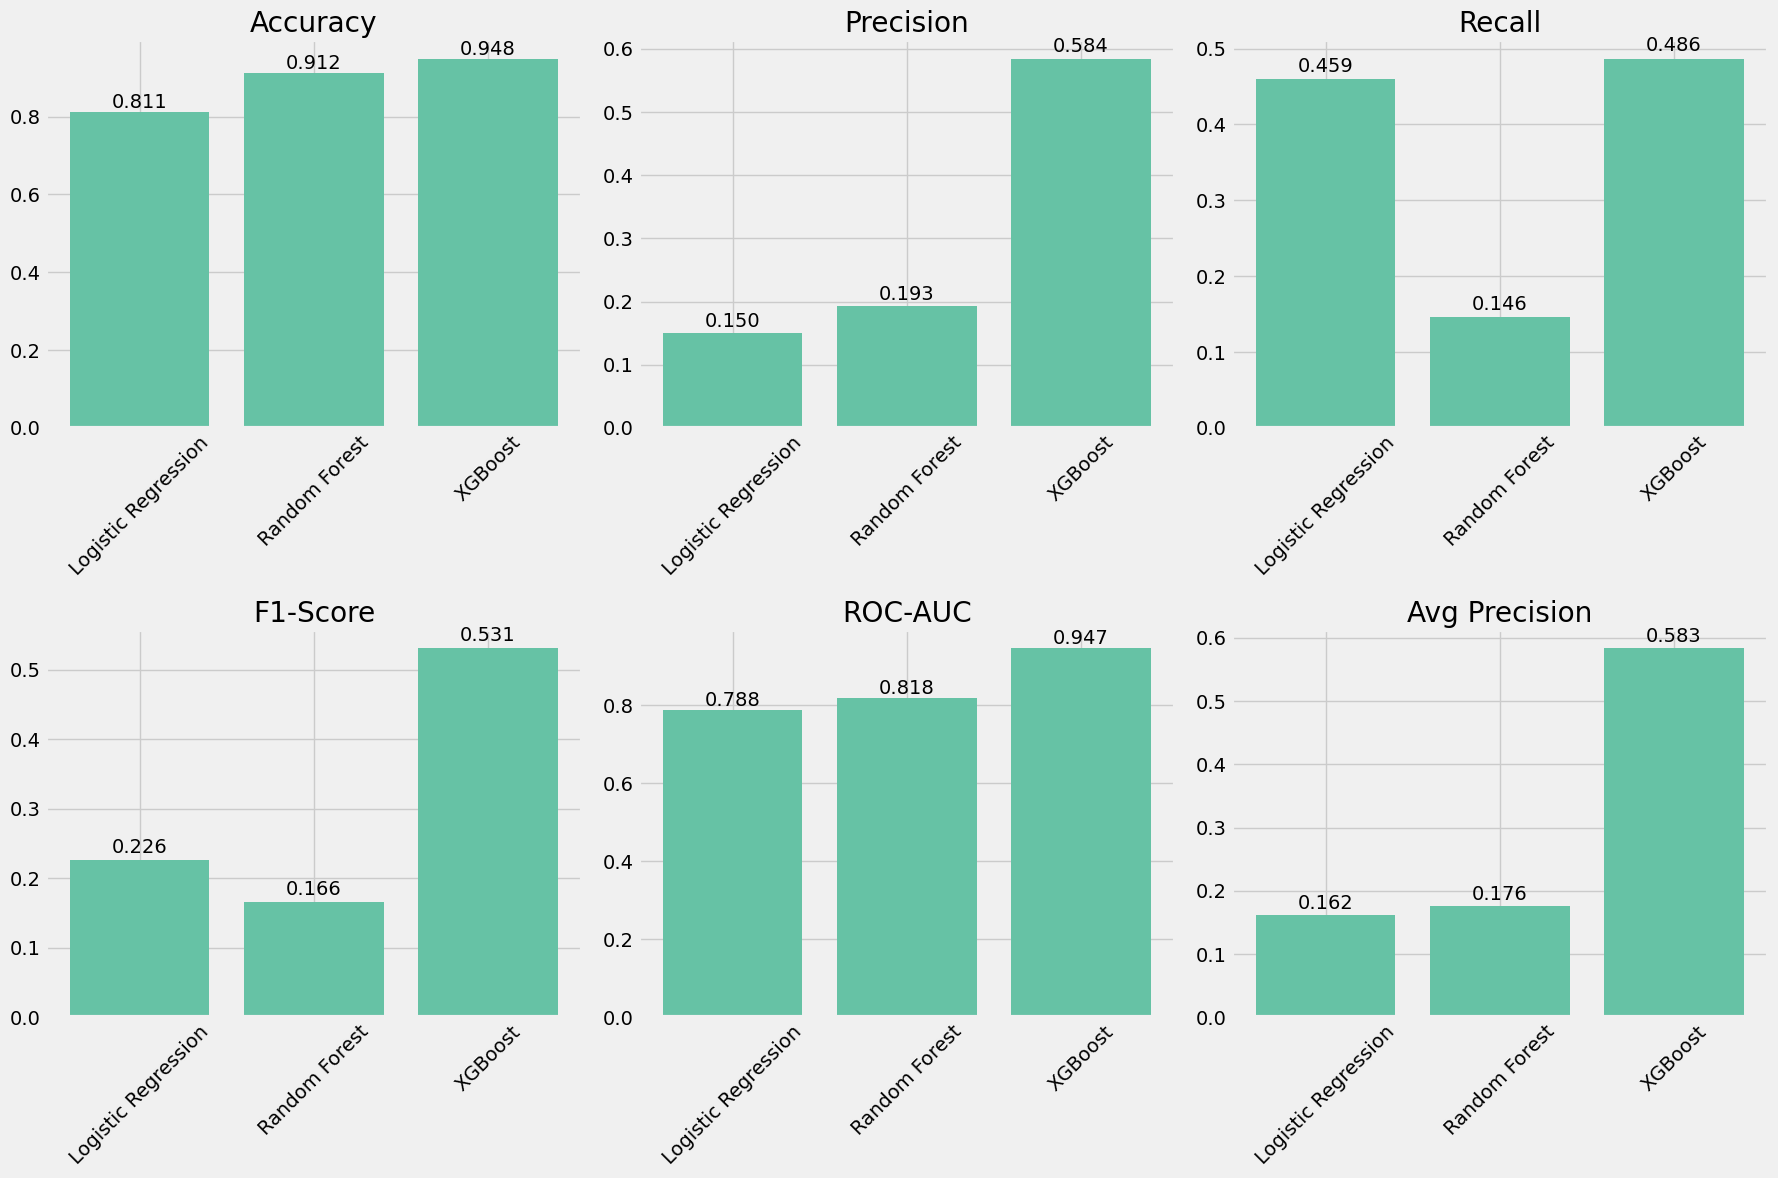

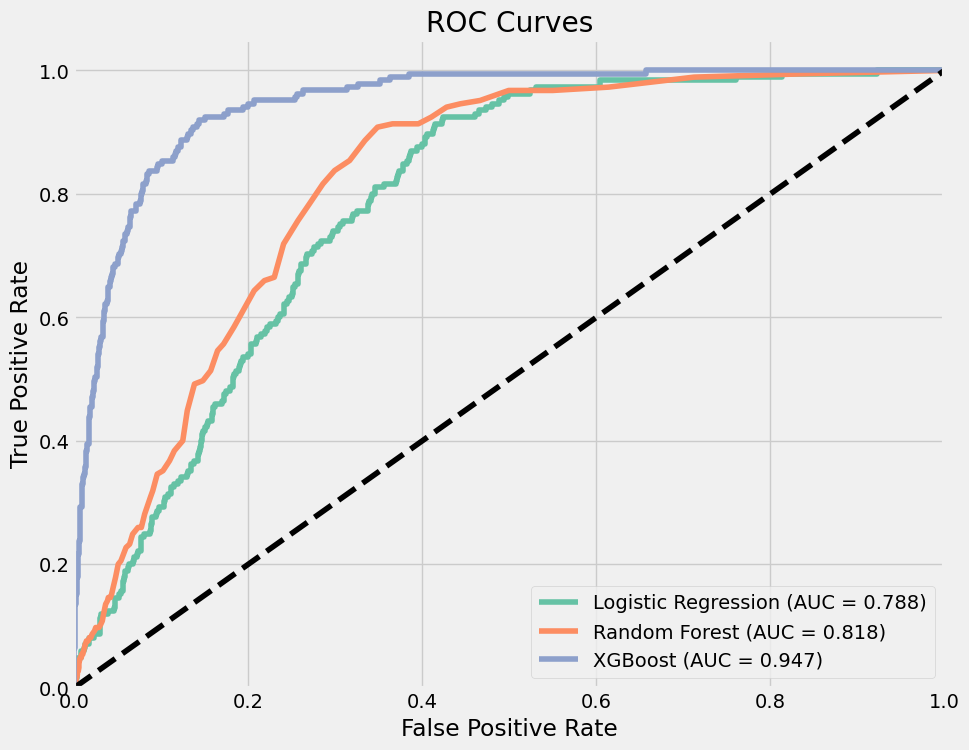

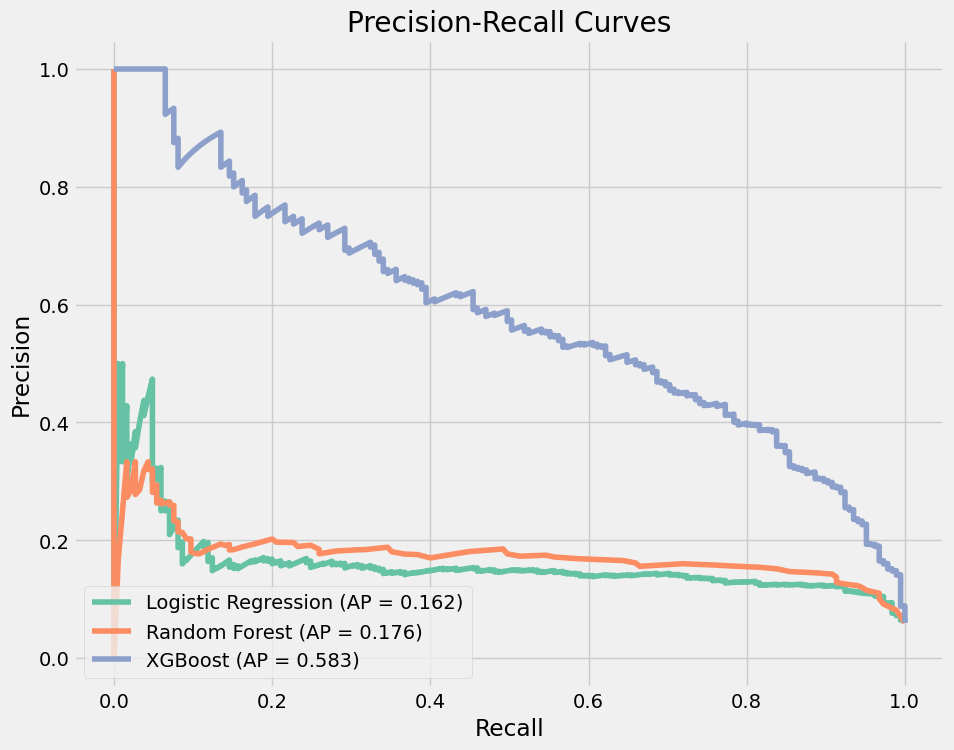

Best model: XGBoost


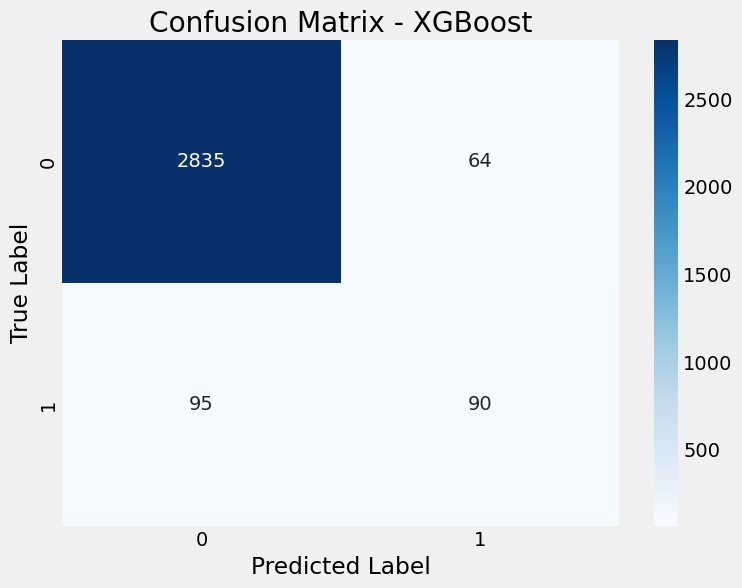


Classification Report - XGBoost:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      2899
           1       0.58      0.49      0.53       185

    accuracy                           0.95      3084
   macro avg       0.78      0.73      0.75      3084
weighted avg       0.94      0.95      0.95      3084



In [21]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Avg Precision']
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

metric_mapping = {
    'Accuracy': 'accuracy',
    'Precision': 'precision', 
    'Recall': 'recall',
    'F1-Score': 'f1',
    'ROC-AUC': 'roc_auc',
    'Avg Precision': 'avg_precision'
}

for i, metric in enumerate(metrics):
    values = [traditional_results[m][metric_mapping[metric]] for m in traditional_results]
    axes[i].bar(traditional_results.keys(), values)
    axes[i].set_title(metric)
    axes[i].tick_params(axis='x', rotation=45)

    for j, v in enumerate(values):
        axes[i].text(j, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
for name, result in traditional_results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc="lower right")
plt.show()

plt.figure(figsize=(10, 8))
for name, result in traditional_results.items():
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, result['y_pred_proba'])
    avg_precision = average_precision_score(y_test, result['y_pred_proba'])
    plt.plot(recall_vals, precision_vals, label=f'{name} (AP = {avg_precision:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc="lower left")
plt.show()

best_model_name = max(traditional_results, key=lambda x: traditional_results[x]['f1'])
best_model = traditional_results[best_model_name]['model']
y_pred_best = traditional_results[best_model_name]['y_pred']

print(f"Best model: {best_model_name}")

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f"\nClassification Report - {best_model_name}:")
print(classification_report(y_test, y_pred_best))